# Recent Versions (5.x) — Deep Dive Analysis
Focused on versions 5.0.0 through 5.8.1 — how sentiment has trended and what's driving it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

STOP_WORDS = set(stopwords.words('english'))
EXTRA_STOP = {'app', 'tira', 'ok', 'use', 'one', 'also', 'get', 'even', 'like',
              'just', 'time', 'please', 'give', 'nice', 'would', 'make', 'much',
              'many', 'good', 'great', 'love', 'really', 'using', 'better', 'best',
              'worst', 'need', 'used', 'well', 'still', 'us', 'take', 'every',
              'want', 'able', 'way', 'never', 'always', 'back', 'go', 'going',
              'come', 'try', 'show', 'will', 'cant', 'dont', 'im', 'ive', 'its',
              'na', 'ka', 'hai', 'nahi', 'bahut', 'aur', 'bad', 'very', 'see'}
ALL_STOP = STOP_WORDS | EXTRA_STOP

THEMES = {
    'Order / Returns':          ['order', 'return', 'exchange', 'cancel', 'cancelled', 'replacement', 'missing'],
    'Product Quality':          ['product', 'quality', 'original', 'fake', 'genuine', 'brand', 'item', 'broken', 'damaged', 'wrong', 'expired'],
    'Delivery / Shipping':      ['delivery', 'ship', 'shipping', 'deliver', 'courier', 'dispatch', 'arrive', 'arrived', 'late', 'delay', 'delayed'],
    'Customer Support':         ['support', 'service', 'customer', 'help', 'response', 'team', 'complaint', 'helpline', 'contact', 'chat', 'call'],
    'Payment / Refund':         ['payment', 'refund', 'cashback', 'money', 'pay', 'paid', 'transaction', 'wallet', 'coupon', 'discount', 'offer'],
    'App Performance':          ['crash', 'hang', 'slow', 'bug', 'error', 'loading', 'load', 'freeze', 'glitch', 'issue', 'problem', 'lag'],
    'UI / User Experience':     ['interface', 'design', 'experience', 'easy', 'difficult', 'navigate', 'search', 'filter', 'layout', 'simple', 'confusing'],
    'Pincode / Availability':   ['pincode', 'pin code', 'area', 'location', 'available', 'unavailable', 'serviceable', 'city', 'zone'],
    'Login / Account':          ['login', 'otp', 'account', 'sign', 'password', 'verify', 'register', 'logout'],
    'Offers / Discounts':       ['offer', 'sale', 'discount', 'coupon', 'deal', 'promo', 'cashback', 'reward', 'point', 'points'],
}

SENT_COLORS = {'Positive': '#2ca02c', 'Neutral': '#bcbd22', 'Negative': '#d62728'}
RATING_COLORS = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

VERSION_ORDER = ['5.0.0', '5.1.1', '5.2.1', '5.3.0', '5.3.1', '5.4.0', '5.5.0', '5.6.0', '5.6.1', '5.8.1']

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in ALL_STOP and len(w) > 2]
    return ' '.join(tokens)

def assign_sentiment(r):
    return 'Negative' if r <= 2 else 'Neutral' if r == 3 else 'Positive'

def detect_themes(text):
    t = str(text).lower()
    matched = [th for th, kws in THEMES.items() if any(k in t for k in kws)]
    return matched if matched else ['Other']

print('Setup complete.')

/Users/shubham.bansla/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Setup complete.


## 1. Load & Filter Recent Versions

In [2]:
df_all = pd.read_csv('AndoridReviews.csv').dropna(subset=['body', 'rating', 'app_version'])
df_all['body'] = df_all['body'].astype(str).str.strip()
df_all = df_all[df_all['body'].str.len() > 1]
df_all['rating'] = df_all['rating'].astype(int)
df_all['sentiment'] = df_all['rating'].apply(assign_sentiment)
df_all['clean_body'] = df_all['body'].apply(clean_text)
df_all['word_count'] = df_all['body'].str.split().str.len()
df_all['polarity'] = df_all['body'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_all['themes'] = df_all['body'].apply(detect_themes)

# Recent = 5.x versions
df = df_all[df_all['app_version'].astype(str).str.startswith('5.')].copy()
# Exclude tiny versions (< 10 reviews) for cleaner charts
valid_versions = df['app_version'].value_counts()
valid_versions = valid_versions[valid_versions >= 10].index.tolist()
df_main = df[df['app_version'].isin(valid_versions)].copy()

sc = df['sentiment'].value_counts()
sp = (sc / len(df) * 100).round(1)

print(f'All-time reviews  : {len(df_all):,}')
print(f'Recent (5.x)      : {len(df):,} reviews across {df["app_version"].nunique()} versions')
print(f'Latest version    : 5.8.1 ({len(df[df["app_version"]=="5.8.1"]):} reviews)')
print(f'\nRecent Sentiment:')
for s in ['Positive', 'Neutral', 'Negative']:
    print(f'  {s:<10}: {sc.get(s,0):>5,}  ({sp.get(s,0):.1f}%)')
print(f'  Avg Rating : {df["rating"].mean():.2f} / 5.00')

All-time reviews  : 8,953
Recent (5.x)      : 1,879 reviews across 10 versions
Latest version    : 5.8.1 (385 reviews)

Recent Sentiment:
  Positive  : 1,048  (55.8%)
  Neutral   :    66  (3.5%)
  Negative  :   765  (40.7%)
  Avg Rating : 3.26 / 5.00


## 2. Version-by-Version Trend

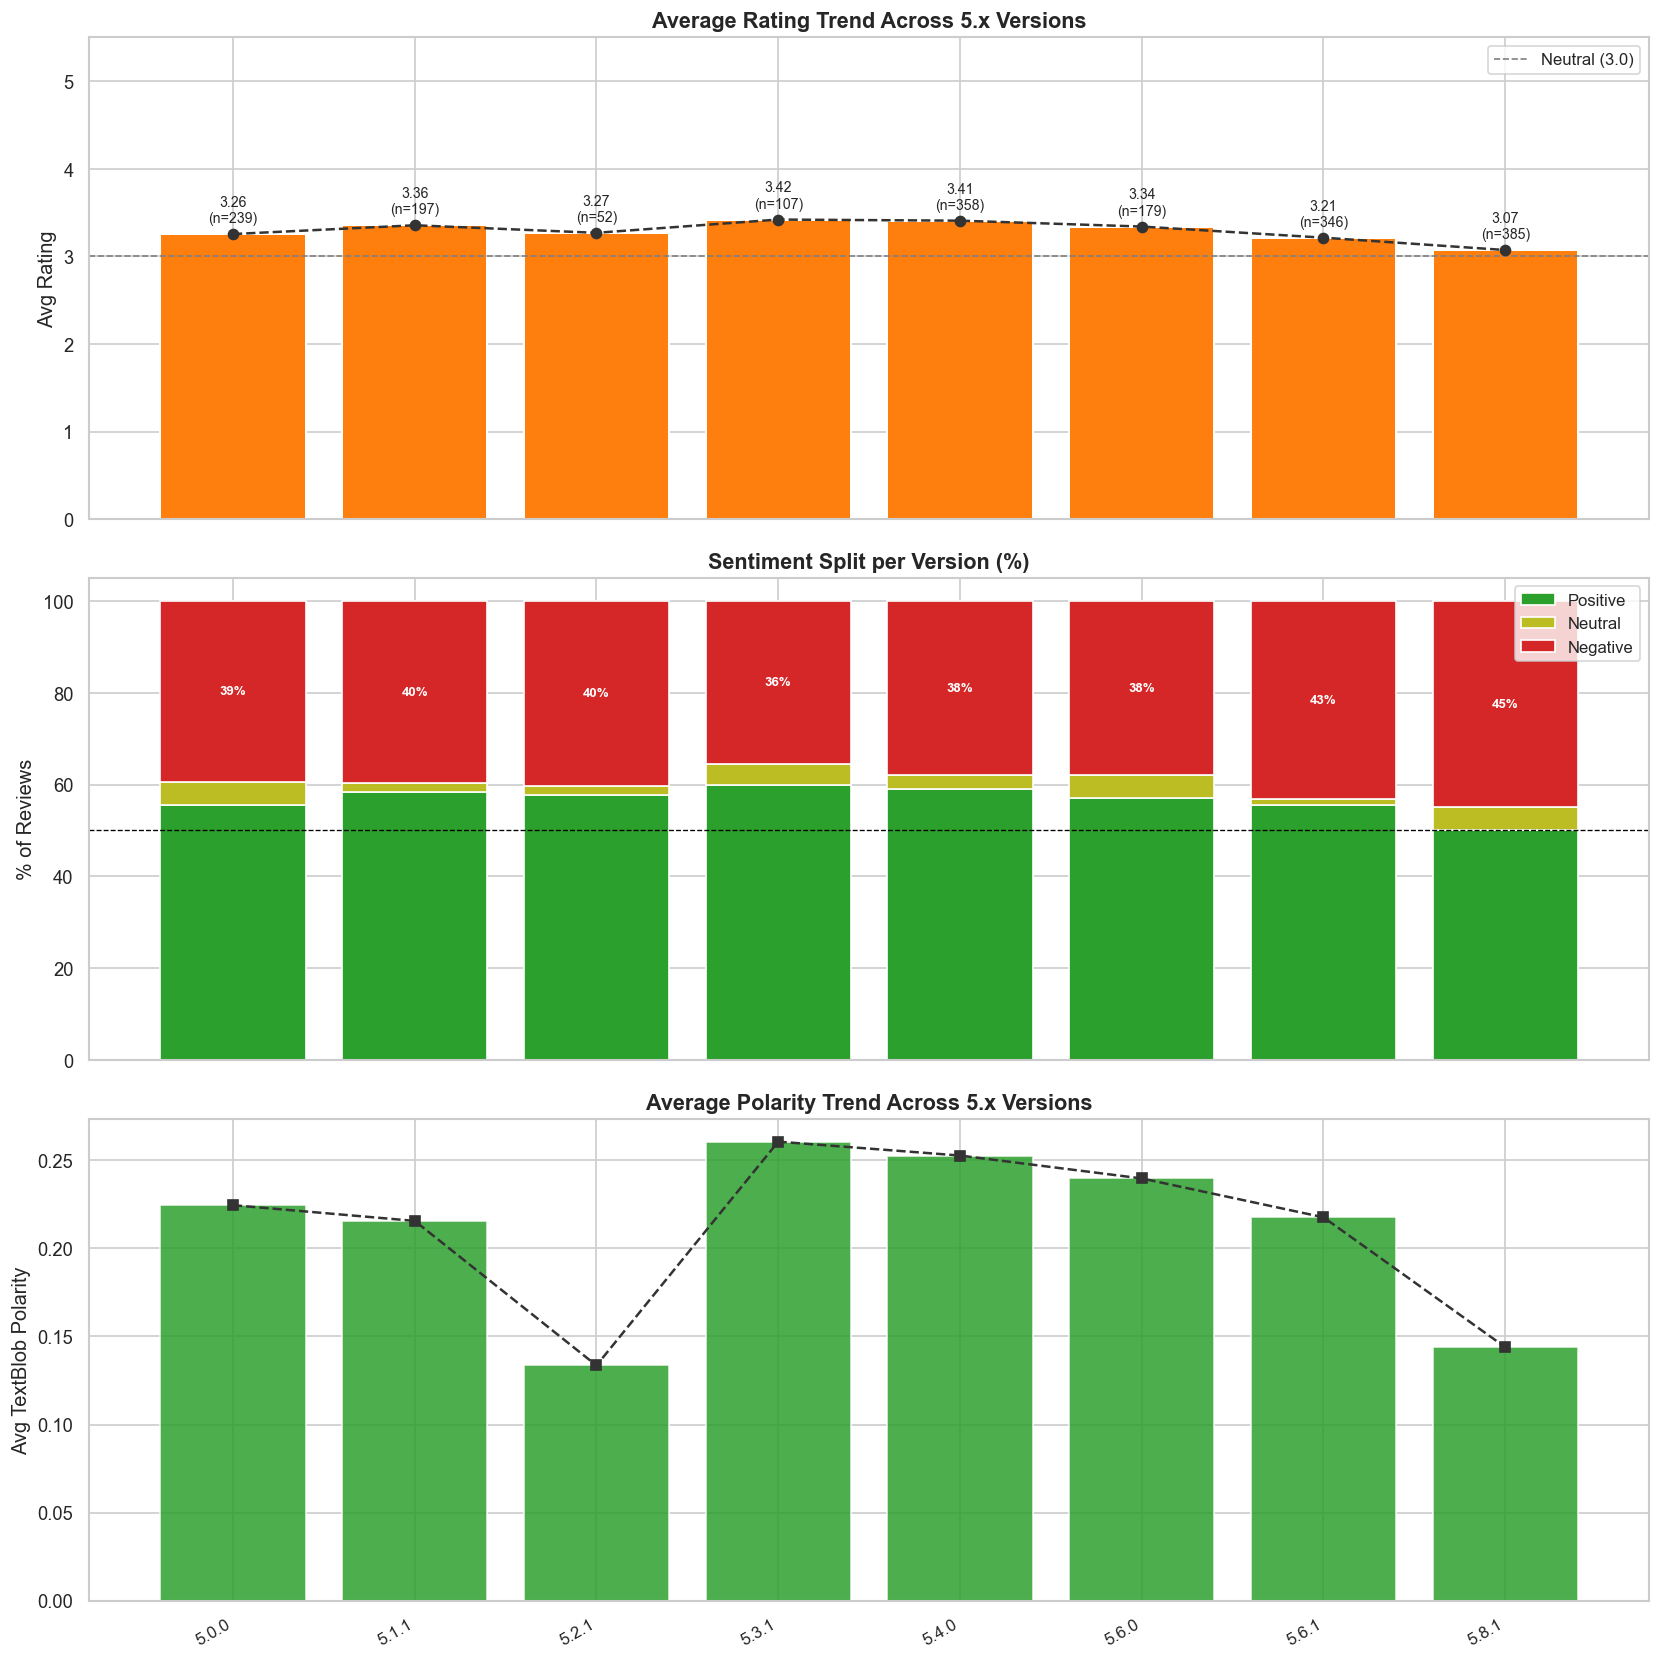


Version summary:
app_version  count  avg_rating   pct_pos   pct_neg
      5.0.0    239    3.255230 55.648536 39.330544
      5.1.1    197    3.355330 58.375635 39.593909
      5.2.1     52    3.269231 57.692308 40.384615
      5.3.1    107    3.420561 59.813084 35.514019
      5.4.0    358    3.407821 58.938547 37.988827
      5.6.0    179    3.340782 56.983240 37.988827
      5.6.1    346    3.213873 55.491329 43.063584
      5.8.1    385    3.072727 50.129870 44.935065


In [3]:
v_stats = df_main.groupby('app_version').agg(
    count       = ('rating', 'count'),
    avg_rating  = ('rating', 'mean'),
    avg_polarity= ('polarity', 'mean'),
    pct_pos     = ('sentiment', lambda x: (x == 'Positive').mean() * 100),
    pct_neg     = ('sentiment', lambda x: (x == 'Negative').mean() * 100),
    pct_neu     = ('sentiment', lambda x: (x == 'Neutral').mean() * 100),
).reset_index()

# Sort by version
order = [v for v in VERSION_ORDER if v in v_stats['app_version'].values]
v_stats['_order'] = v_stats['app_version'].apply(lambda x: order.index(x) if x in order else 99)
v_stats = v_stats.sort_values('_order').reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

x = range(len(v_stats))
xlabels = v_stats['app_version'].tolist()

# --- Avg rating trend ---
bar_colors = ['#2ca02c' if r >= 4 else '#ff7f0e' if r >= 3 else '#d62728' for r in v_stats['avg_rating']]
axes[0].bar(x, v_stats['avg_rating'], color=bar_colors, edgecolor='white', linewidth=1.2)
axes[0].plot(x, v_stats['avg_rating'], 'o--', color='#333', linewidth=1.5, markersize=6, zorder=5)
axes[0].axhline(3, color='gray', linestyle='--', linewidth=1, label='Neutral (3.0)')
axes[0].set_ylim(0, 5.5)
axes[0].set_ylabel('Avg Rating', fontsize=12)
axes[0].set_title('Average Rating Trend Across 5.x Versions', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
for xi, (_, row) in zip(x, v_stats.iterrows()):
    axes[0].text(xi, row['avg_rating'] + 0.1, f"{row['avg_rating']:.2f}\n(n={int(row['count'])})",
                 ha='center', va='bottom', fontsize=8.5)

# --- Sentiment % stacked bar ---
axes[1].bar(x, v_stats['pct_pos'], label='Positive', color='#2ca02c', edgecolor='white')
axes[1].bar(x, v_stats['pct_neu'], bottom=v_stats['pct_pos'], label='Neutral', color='#bcbd22', edgecolor='white')
axes[1].bar(x, v_stats['pct_neg'], bottom=v_stats['pct_pos'] + v_stats['pct_neu'], label='Negative', color='#d62728', edgecolor='white')
axes[1].axhline(50, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('% of Reviews', fontsize=12)
axes[1].set_title('Sentiment Split per Version (%)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper right')
for xi, (_, row) in zip(x, v_stats.iterrows()):
    axes[1].text(xi, row['pct_neg'] / 2 + row['pct_pos'] + row['pct_neu'],
                 f"{row['pct_neg']:.0f}%", ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# --- Avg polarity trend ---
pol_colors = ['#2ca02c' if p >= 0 else '#d62728' for p in v_stats['avg_polarity']]
axes[2].bar(x, v_stats['avg_polarity'], color=pol_colors, edgecolor='white', alpha=0.85)
axes[2].plot(x, v_stats['avg_polarity'], 's--', color='#333', linewidth=1.5, markersize=6, zorder=5)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('Avg TextBlob Polarity', fontsize=12)
axes[2].set_title('Average Polarity Trend Across 5.x Versions', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xticks(list(x))
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=10)

plt.tight_layout()
plt.savefig('r01_version_trend.png', bbox_inches='tight')
plt.show()

print('\nVersion summary:')
print(v_stats[['app_version','count','avg_rating','pct_pos','pct_neg']].to_string(index=False))

## 3. Latest Version (5.8.1) vs Previous (5.6.1) Deep Comparison


--- v5.8.1 (Latest) (385 reviews) ---
  Avg Rating : 3.07
  Positive   : 193 (50.1%)
  Neutral    : 19 (4.9%)
  Negative   : 173 (44.9%)
  Avg Polarity: 0.144
  Avg Words   : 22.0

--- v5.6.1 (Previous) (346 reviews) ---
  Avg Rating : 3.21
  Positive   : 192 (55.5%)
  Neutral    : 5 (1.4%)
  Negative   : 149 (43.1%)
  Avg Polarity: 0.218
  Avg Words   : 21.5


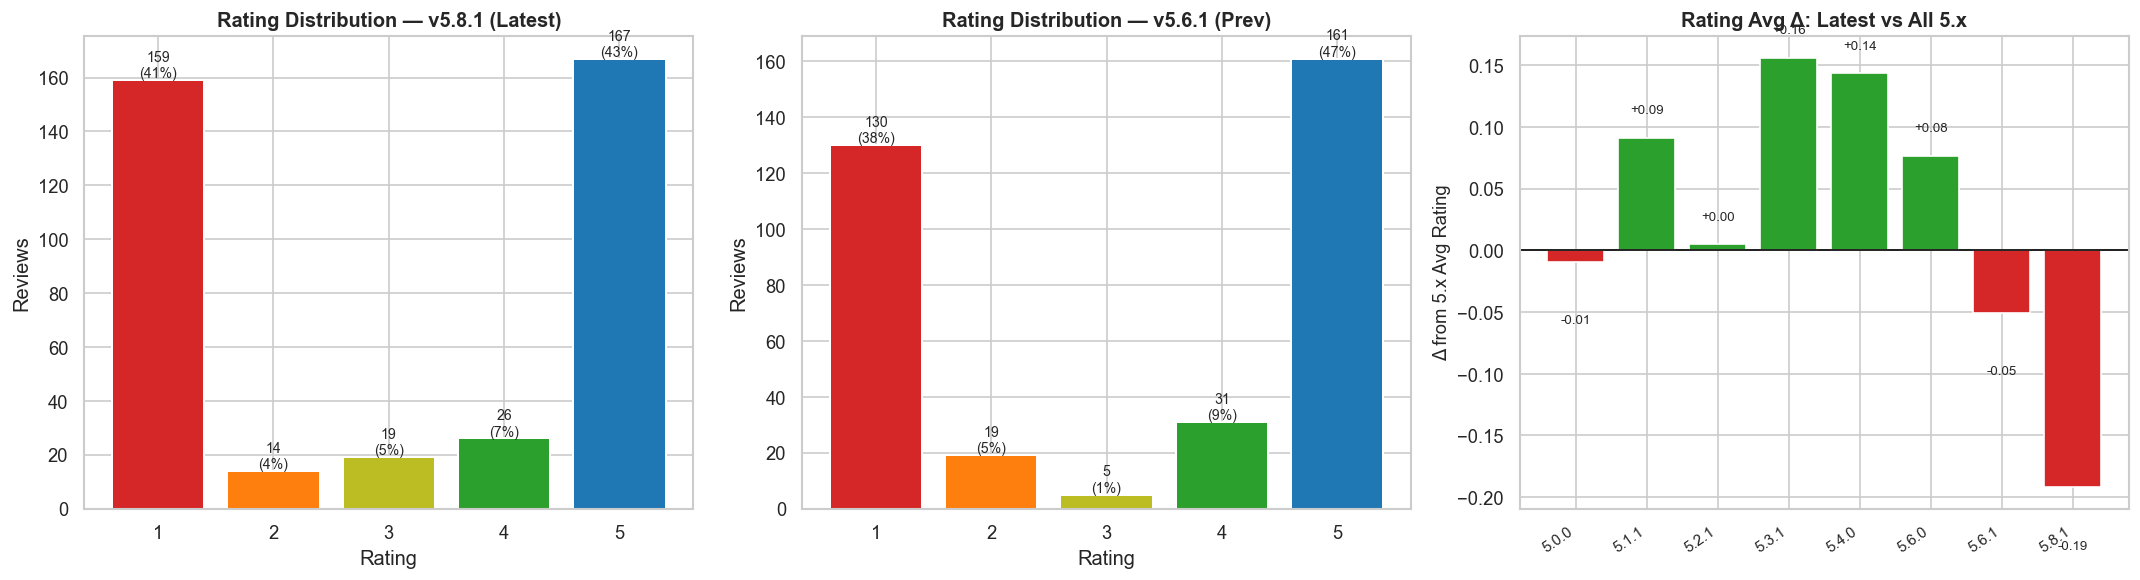

In [4]:
latest  = df[df['app_version'] == '5.8.1'].copy()
prev    = df[df['app_version'] == '5.6.1'].copy()

def version_summary(vdf, label):
    sc = vdf['sentiment'].value_counts()
    sp = (sc / len(vdf) * 100).round(1)
    print(f'\n--- {label} ({len(vdf)} reviews) ---')
    print(f'  Avg Rating : {vdf["rating"].mean():.2f}')
    print(f'  Positive   : {sc.get("Positive",0)} ({sp.get("Positive",0)}%)')
    print(f'  Neutral    : {sc.get("Neutral",0)} ({sp.get("Neutral",0)}%)')
    print(f'  Negative   : {sc.get("Negative",0)} ({sp.get("Negative",0)}%)')
    print(f'  Avg Polarity: {vdf["polarity"].mean():.3f}')
    print(f'  Avg Words   : {vdf["word_count"].mean():.1f}')

version_summary(latest, 'v5.8.1 (Latest)')
version_summary(prev,   'v5.6.1 (Previous)')

# Side-by-side rating distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (vdf, label, color) in enumerate([
    (latest, 'v5.8.1 (Latest)', '#1f77b4'),
    (prev,   'v5.6.1 (Prev)',   '#9467bd'),
]):
    rc = vdf['rating'].value_counts().sort_index().reindex([1,2,3,4,5], fill_value=0)
    axes[i].bar(rc.index, rc.values, color=RATING_COLORS, edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'Rating Distribution — {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Rating'); axes[i].set_ylabel('Reviews')
    axes[i].set_xticks([1,2,3,4,5])
    total = len(vdf)
    for r, v in zip(rc.index, rc.values):
        axes[i].text(r, v + 1, f'{v}\n({v/total*100:.0f}%)', ha='center', fontsize=8.5)

# Delta chart
axes[2].set_title('Rating Avg Δ: Latest vs All 5.x', fontsize=12, fontweight='bold')
overall_avg = df['rating'].mean()
v_delta = v_stats.copy()
v_delta['delta'] = v_delta['avg_rating'] - overall_avg
delta_colors = ['#2ca02c' if d >= 0 else '#d62728' for d in v_delta['delta']]
axes[2].bar(range(len(v_delta)), v_delta['delta'], color=delta_colors, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_xticks(range(len(v_delta)))
axes[2].set_xticklabels(v_delta['app_version'].tolist(), rotation=35, ha='right', fontsize=9)
axes[2].set_ylabel('Δ from 5.x Avg Rating', fontsize=11)
for xi, (_, row) in enumerate(v_delta.iterrows()):
    axes[2].text(xi, row['delta'] + (0.02 if row['delta'] >= 0 else -0.05),
                 f"{row['delta']:+.2f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('r02_version_comparison.png', bbox_inches='tight')
plt.show()

## 4. Theme Analysis — 5.x Versions Overall

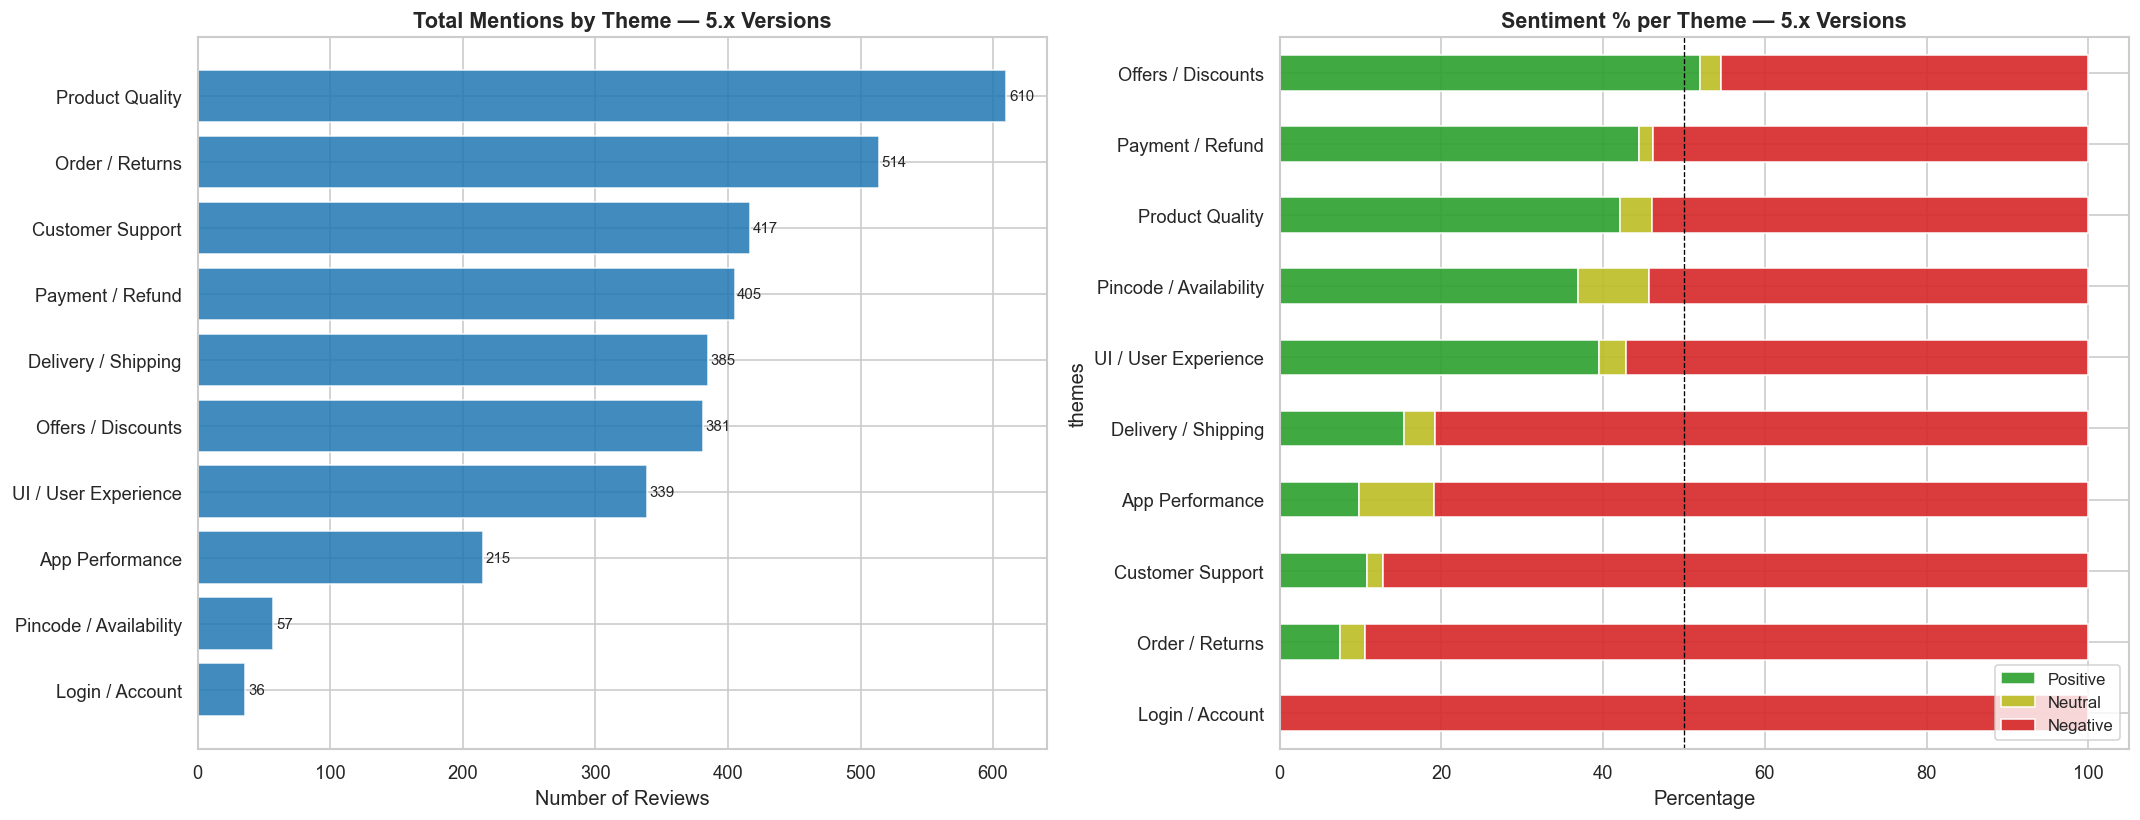

In [5]:
theme_df = df.explode('themes')
theme_sent = theme_df.groupby(['themes', 'sentiment']).size().unstack(fill_value=0)
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in theme_sent.columns:
        theme_sent[col] = 0
theme_sent['total'] = theme_sent[['Positive','Neutral','Negative']].sum(axis=1)
theme_sent = theme_sent.sort_values('total', ascending=False)
theme_norm = theme_sent[['Positive','Neutral','Negative']].div(theme_sent['total'], axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Total mentions
plot_t = theme_sent[theme_sent.index != 'Other'].sort_values('total', ascending=True)
axes[0].barh(plot_t.index, plot_t['total'], color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0].set_title('Total Mentions by Theme — 5.x Versions', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
for i, (idx, row) in enumerate(plot_t.iterrows()):
    axes[0].text(row['total'] + 2, i, str(int(row['total'])), va='center', fontsize=9)

# Stacked sentiment %
plot_n = theme_norm.drop('Other', errors='ignore').sort_values('Negative', ascending=False)
plot_n[['Positive','Neutral','Negative']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#2ca02c','#bcbd22','#d62728'], edgecolor='white', alpha=0.9
)
axes[1].set_title('Sentiment % per Theme — 5.x Versions', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Percentage')
axes[1].axvline(50, color='black', linewidth=0.8, linestyle='--')
axes[1].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('r03_theme_overview.png', bbox_inches='tight')
plt.show()

## 5. Pain Points — How They Evolved Across 5.x Versions

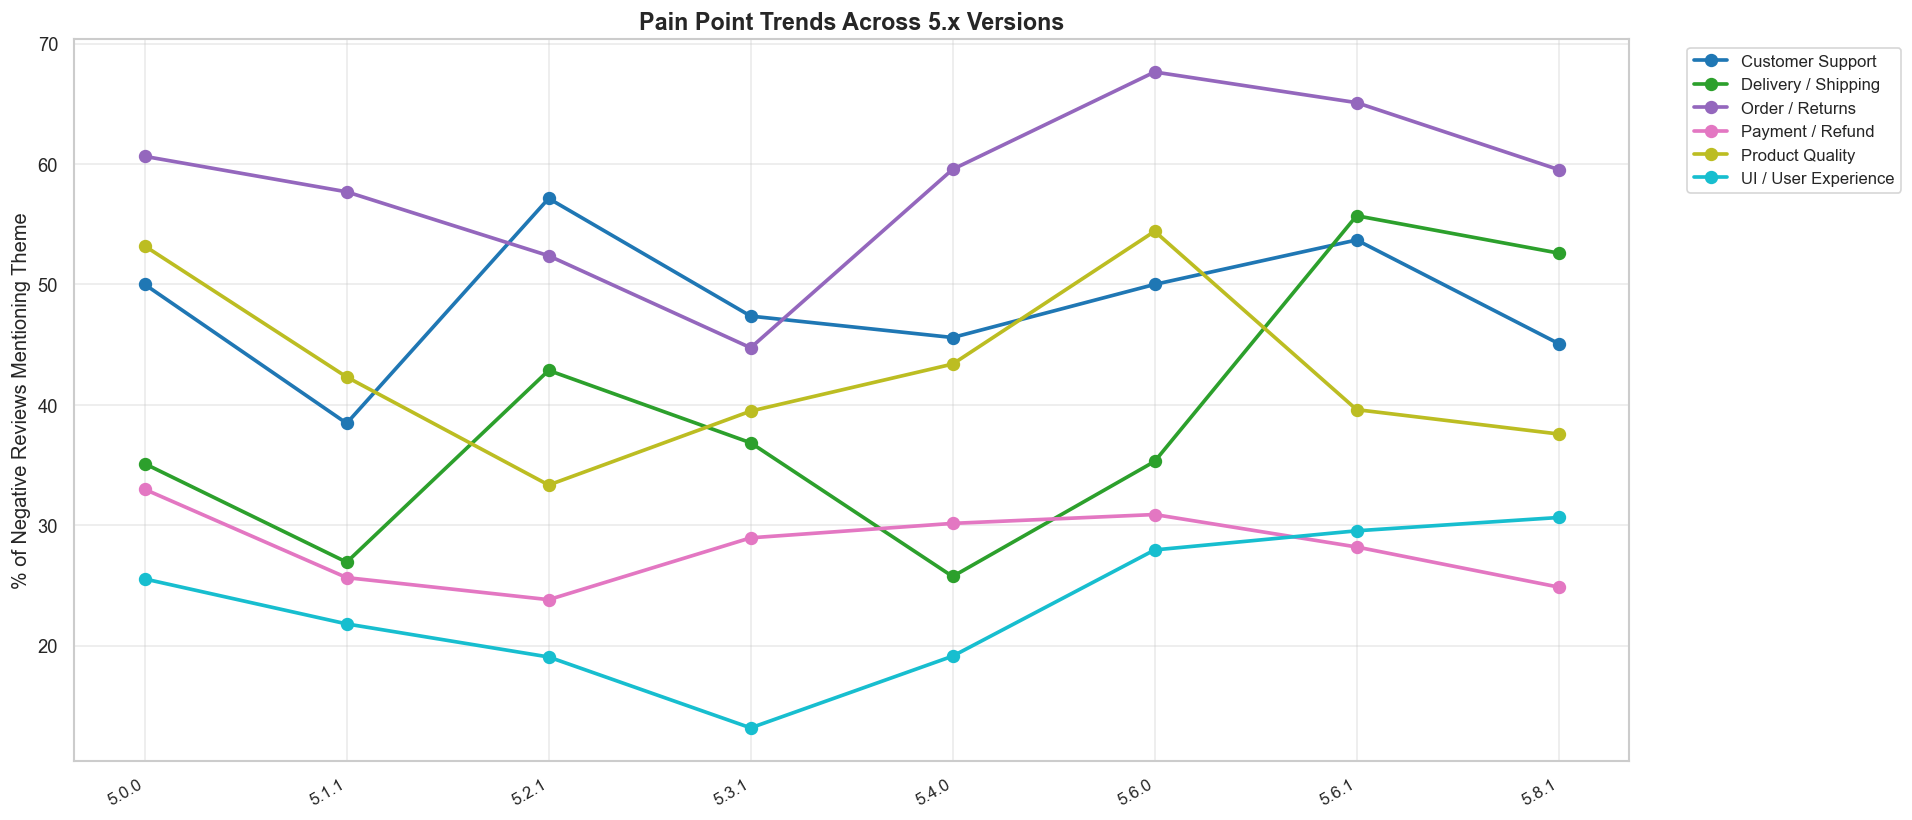


Pain point % by version (negative reviews):
app_version           5.0.0  5.1.1  5.2.1  5.3.1  5.4.0  5.6.0  5.6.1  5.8.1
themes                                                                      
Customer Support       50.0   38.5   57.1   47.4   45.6   50.0   53.7   45.1
Delivery / Shipping    35.1   26.9   42.9   36.8   25.7   35.3   55.7   52.6
Order / Returns        60.6   57.7   52.4   44.7   59.6   67.6   65.1   59.5
Payment / Refund       33.0   25.6   23.8   28.9   30.1   30.9   28.2   24.9
Product Quality        53.2   42.3   33.3   39.5   43.4   54.4   39.6   37.6
UI / User Experience   25.5   21.8   19.0   13.2   19.1   27.9   29.5   30.6


In [6]:
# For each version, compute % of reviews mentioning each theme (among negative reviews)
neg_df = df_main[df_main['sentiment'] == 'Negative'].copy()
neg_theme_df = neg_df.explode('themes')
neg_theme_df = neg_theme_df[neg_theme_df['themes'] != 'Other']

# Pivot: rows=theme, cols=version, values=count
neg_pivot = neg_theme_df.groupby(['themes','app_version']).size().unstack(fill_value=0)
neg_count_per_ver = neg_df.groupby('app_version').size()
# Normalize to % of negative reviews per version
neg_pivot_pct = neg_pivot.div(neg_count_per_ver, axis=1) * 100
# Keep only top themes
top_themes = neg_theme_df['themes'].value_counts().head(6).index.tolist()
neg_pivot_pct = neg_pivot_pct.loc[neg_pivot_pct.index.isin(top_themes)]

# Sort versions
v_cols = [v for v in VERSION_ORDER if v in neg_pivot_pct.columns]
neg_pivot_pct = neg_pivot_pct[v_cols]

fig, ax = plt.subplots(figsize=(16, 7))
colors_themes = plt.cm.tab10(np.linspace(0, 1, len(top_themes)))
for theme, color in zip(neg_pivot_pct.index, colors_themes):
    ax.plot(range(len(v_cols)), neg_pivot_pct.loc[theme, v_cols],
            marker='o', linewidth=2.2, label=theme, color=color, markersize=7)

ax.set_xticks(range(len(v_cols)))
ax.set_xticklabels(v_cols, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('% of Negative Reviews Mentioning Theme', fontsize=12)
ax.set_title('Pain Point Trends Across 5.x Versions', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, bbox_to_anchor=(1.18, 1))
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('r04_pain_point_trends.png', bbox_inches='tight')
plt.show()

print('\nPain point % by version (negative reviews):')
print(neg_pivot_pct.round(1).to_string())

## 6. Latest Version (5.8.1) — Pain Points Breakdown

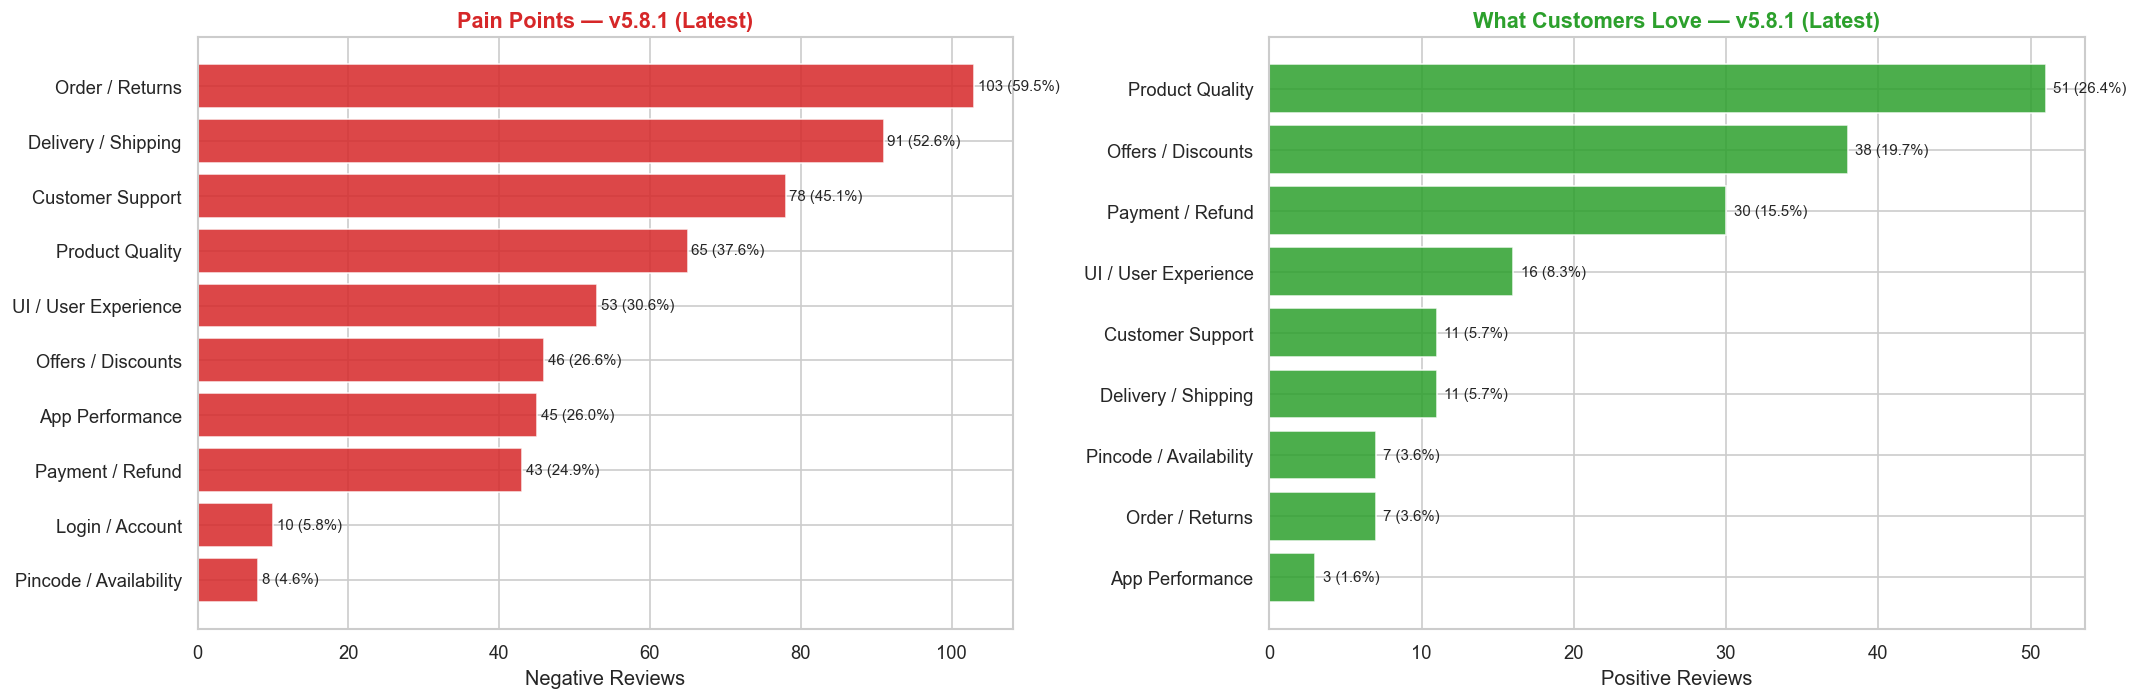


v5.8.1: 385 reviews | 173 negative | 193 positive


In [7]:
latest_neg = latest[latest['sentiment'] == 'Negative'].copy()
latest_pos = latest[latest['sentiment'] == 'Positive'].copy()

latest_neg_theme = latest_neg.explode('themes')
latest_pos_theme = latest_pos.explode('themes')

neg_counts = latest_neg_theme[latest_neg_theme['themes'] != 'Other']['themes'].value_counts()
pos_counts = latest_pos_theme[latest_pos_theme['themes'] != 'Other']['themes'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Pain points in 5.8.1
nc_sorted = neg_counts.sort_values(ascending=True)
axes[0].barh(nc_sorted.index, nc_sorted.values, color='#d62728', edgecolor='white', alpha=0.85)
axes[0].set_title('Pain Points — v5.8.1 (Latest)', fontsize=13, fontweight='bold', color='#d62728')
axes[0].set_xlabel('Negative Reviews')
total_neg_l = len(latest_neg)
for i, (theme, val) in enumerate(nc_sorted.items()):
    axes[0].text(val + 0.5, i, f'{val} ({val/total_neg_l*100:.1f}%)', va='center', fontsize=9)

# What customers love in 5.8.1
pc_sorted = pos_counts.sort_values(ascending=True)
axes[1].barh(pc_sorted.index, pc_sorted.values, color='#2ca02c', edgecolor='white', alpha=0.85)
axes[1].set_title('What Customers Love — v5.8.1 (Latest)', fontsize=13, fontweight='bold', color='#2ca02c')
axes[1].set_xlabel('Positive Reviews')
total_pos_l = len(latest_pos)
for i, (theme, val) in enumerate(pc_sorted.items()):
    axes[1].text(val + 0.5, i, f'{val} ({val/total_pos_l*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('r05_latest_version_themes.png', bbox_inches='tight')
plt.show()

print(f'\nv5.8.1: {len(latest)} reviews | {len(latest_neg)} negative | {len(latest_pos)} positive')

## 7. Word Clouds — Latest Version (5.8.1)

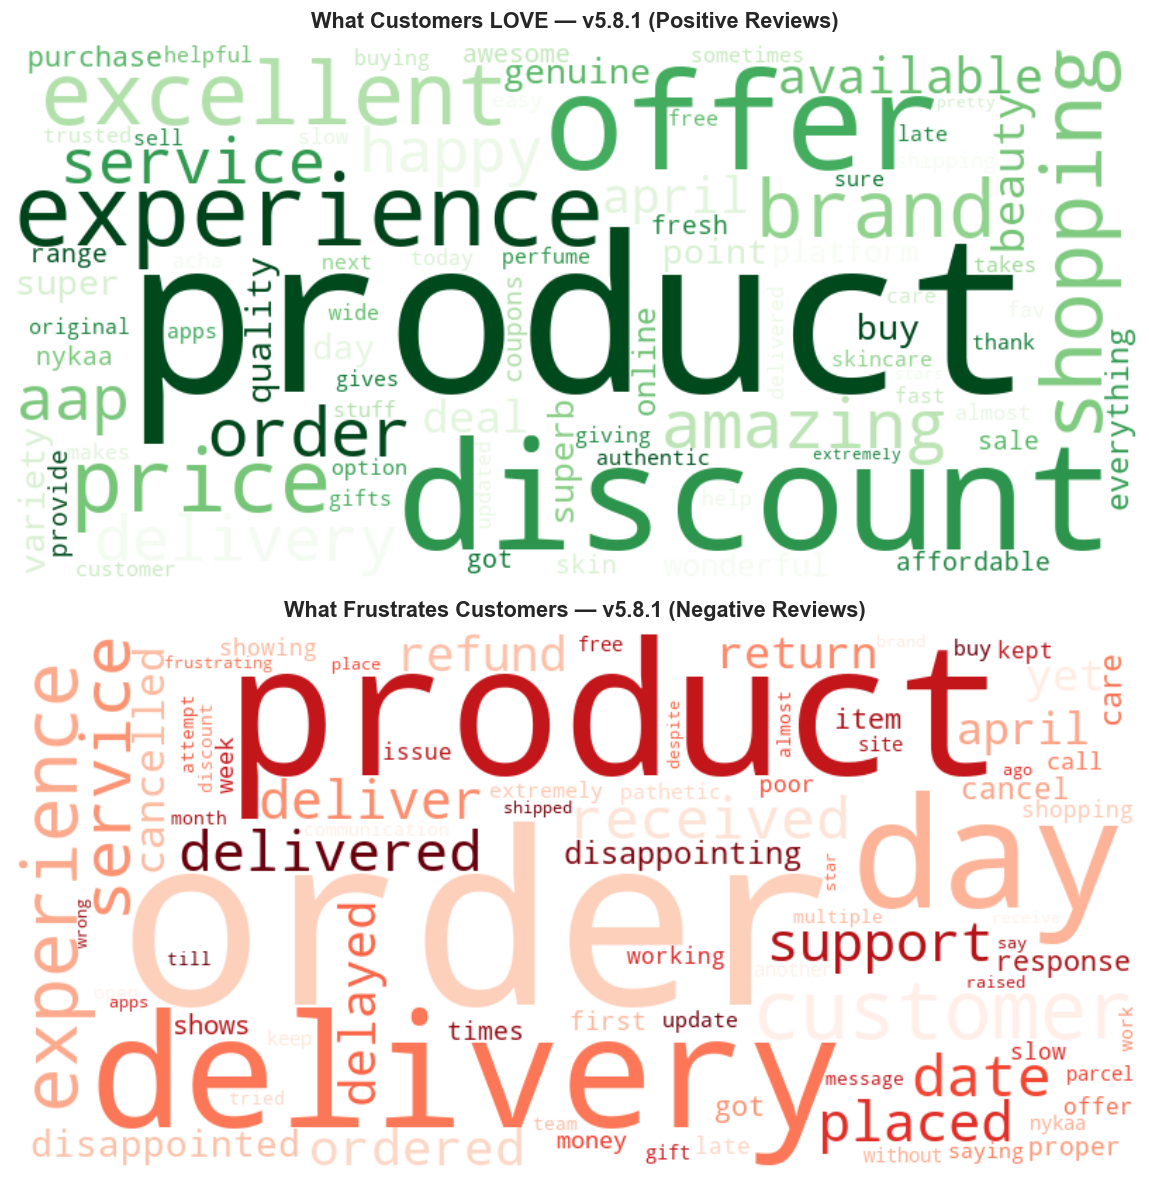

In [8]:
def make_wc(text, colormap, title, ax):
    wc = WordCloud(width=800, height=380, background_color='white',
                   colormap=colormap, max_words=80, collocations=False,
                   min_font_size=8).generate(text if text.strip() else 'no text')
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

pos_text = ' '.join(latest_pos['clean_body'])
neg_text = ' '.join(latest_neg['clean_body'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
make_wc(pos_text, 'Greens', 'What Customers LOVE — v5.8.1 (Positive Reviews)', axes[0])
make_wc(neg_text, 'Reds',   'What Frustrates Customers — v5.8.1 (Negative Reviews)', axes[1])
plt.tight_layout()
plt.savefig('r06_latest_wordclouds.png', bbox_inches='tight')
plt.show()

## 8. Top Keywords — 5.x Negative vs Positive

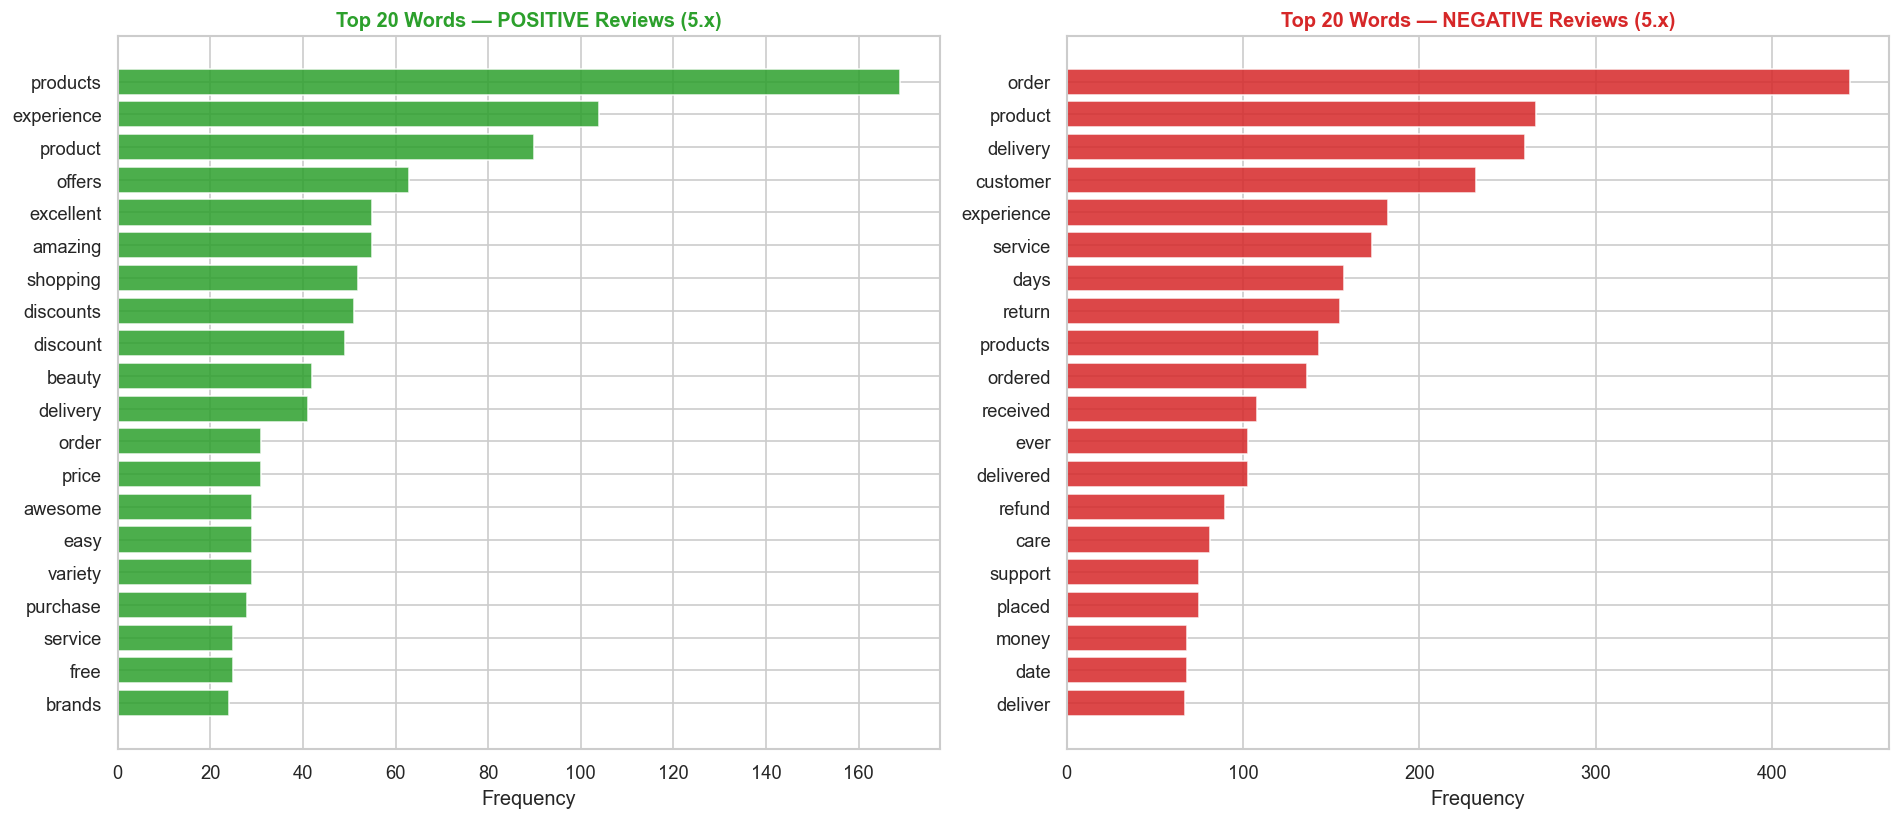

In [9]:
all_neg_text = ' '.join(df[df['sentiment'] == 'Negative']['clean_body'])
all_pos_text = ' '.join(df[df['sentiment'] == 'Positive']['clean_body'])

neg_words = Counter(all_neg_text.split()).most_common(20)
pos_words = Counter(all_pos_text.split()).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pw, pc = zip(*pos_words)
axes[0].barh(list(pw)[::-1], list(pc)[::-1], color='#2ca02c', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 20 Words — POSITIVE Reviews (5.x)', fontsize=12, fontweight='bold', color='#2ca02c')
axes[0].set_xlabel('Frequency')

nw, nc_w = zip(*neg_words)
axes[1].barh(list(nw)[::-1], list(nc_w)[::-1], color='#d62728', edgecolor='white', alpha=0.85)
axes[1].set_title('Top 20 Words — NEGATIVE Reviews (5.x)', fontsize=12, fontweight='bold', color='#d62728')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('r07_keywords.png', bbox_inches='tight')
plt.show()

## 9. TF-IDF — Distinctive Phrases in Latest Version (5.8.1)

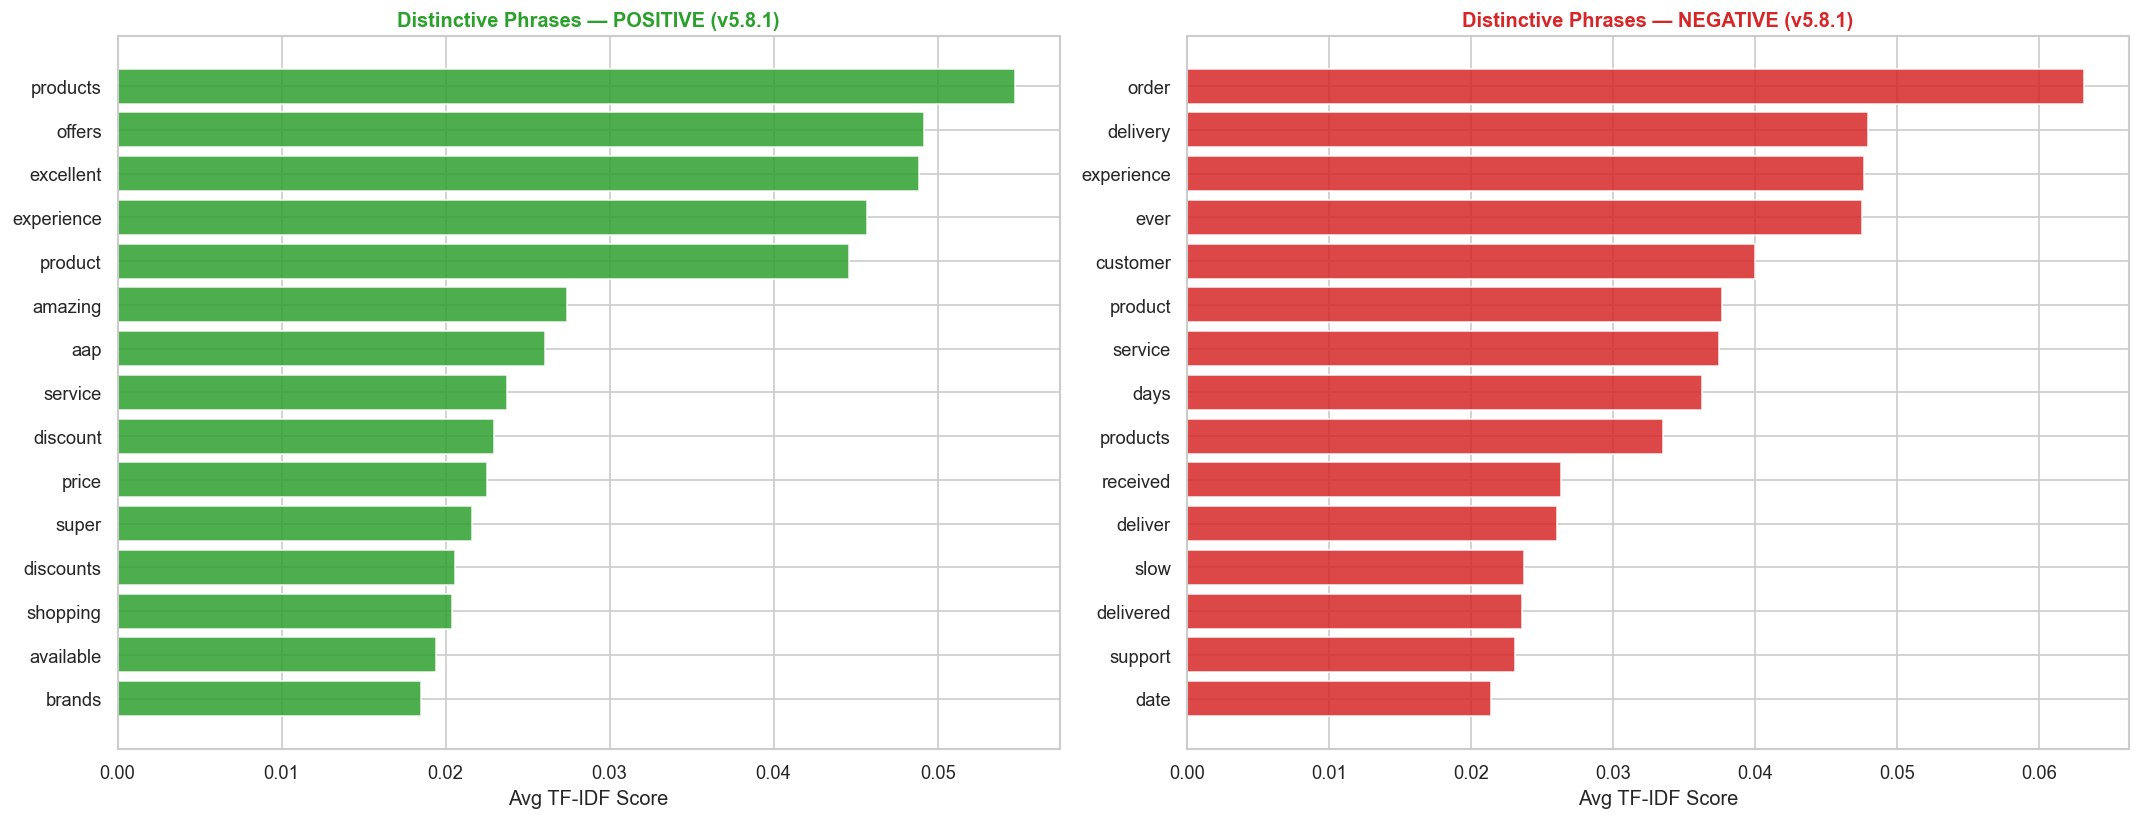

Top distinctive phrases in v5.8.1 NEGATIVE reviews:
  order                          0.0632
  delivery                       0.0480
  experience                     0.0477
  ever                           0.0475
  customer                       0.0400
  product                        0.0377
  service                        0.0375
  days                           0.0363
  products                       0.0335
  received                       0.0264

Top distinctive phrases in v5.8.1 POSITIVE reviews:
  products                       0.0547
  offers                         0.0492
  excellent                      0.0488
  experience                     0.0457
  product                        0.0446
  amazing                        0.0274
  aap                            0.0261
  service                        0.0238
  discount                       0.0230
  price                          0.0225


In [10]:
# Compare 5.8.1 vs all other 5.x to find what's UNIQUE about the latest
latest_neg_texts = latest_neg['clean_body'].tolist()
latest_pos_texts = latest_pos['clean_body'].tolist()

def top_tfidf(texts, top_n=15):
    if len(texts) < 5:
        return []
    tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
    mat = tfidf.fit_transform(texts)
    feat = np.array(tfidf.get_feature_names_out())
    mean_scores = mat.mean(axis=0).A1
    top_idx = mean_scores.argsort()[-top_n:][::-1]
    return list(zip(feat[top_idx], mean_scores[top_idx]))

neg_tfidf = top_tfidf(latest_neg_texts)
pos_tfidf = top_tfidf(latest_pos_texts)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if pos_tfidf:
    pw2, pv2 = zip(*pos_tfidf)
    axes[0].barh(list(pw2)[::-1], list(pv2)[::-1], color='#2ca02c', edgecolor='white', alpha=0.85)
    axes[0].set_title('Distinctive Phrases — POSITIVE (v5.8.1)', fontsize=12, fontweight='bold', color='#2ca02c')
    axes[0].set_xlabel('Avg TF-IDF Score')

if neg_tfidf:
    nw2, nv2 = zip(*neg_tfidf)
    axes[1].barh(list(nw2)[::-1], list(nv2)[::-1], color='#d62728', edgecolor='white', alpha=0.85)
    axes[1].set_title('Distinctive Phrases — NEGATIVE (v5.8.1)', fontsize=12, fontweight='bold', color='#d62728')
    axes[1].set_xlabel('Avg TF-IDF Score')

plt.tight_layout()
plt.savefig('r08_tfidf_latest.png', bbox_inches='tight')
plt.show()

print('Top distinctive phrases in v5.8.1 NEGATIVE reviews:')
for p, s in (neg_tfidf[:10] if neg_tfidf else []):
    print(f'  {p:<30} {s:.4f}')
print('\nTop distinctive phrases in v5.8.1 POSITIVE reviews:')
for p, s in (pos_tfidf[:10] if pos_tfidf else []):
    print(f'  {p:<30} {s:.4f}')

## 10. Sample Reviews — Latest Version Pain Points

In [11]:
top_neg_themes = neg_counts.head(5).index.tolist()
top_pos_themes = pos_counts.head(3).index.tolist()

def sample_reviews(source_df, theme_name, n=3):
    subset = source_df[source_df['themes'].apply(lambda x: theme_name in x)]
    return subset.nlargest(n, 'word_count')[['rating', 'body']]

print('=' * 70)
print('v5.8.1 — TOP NEGATIVE REVIEW SAMPLES BY THEME')
print('=' * 70)
for theme in top_neg_themes:
    print(f'\n--- {theme.upper()} ---')
    samples = sample_reviews(latest_neg, theme, n=2)
    for _, row in samples.iterrows():
        print(f'  [Rating {row.rating}] {str(row.body)[:250]}')

print('\n' + '=' * 70)
print('v5.8.1 — TOP POSITIVE REVIEW SAMPLES BY THEME')
print('=' * 70)
for theme in top_pos_themes:
    print(f'\n--- {theme.upper()} ---')
    samples = sample_reviews(latest_pos, theme, n=2)
    for _, row in samples.iterrows():
        print(f'  [Rating {row.rating}] {str(row.body)[:250]}')

v5.8.1 — TOP NEGATIVE REVIEW SAMPLES BY THEME

--- ORDER / RETURNS ---
  [Rating 1] Tira app is the worst app I have ever experienced in my past days I have ordered my product from Tira because of my trust in it I have ordered my product from Tira on 13th of April and it should be delivered on 20 of April 26 but still I didn't get m
  [Rating 1] worst app ever . Don't buy from this app. I ordered from the tira a second time . 1. I received a different and damaged item . 2. fake advertisement . I have shared the images with your customer team. I made a purchase of 1300 Rs in which I received 

--- DELIVERY / SHIPPING ---
  [Rating 1] Tira app is the worst app I have ever experienced in my past days I have ordered my product from Tira because of my trust in it I have ordered my product from Tira on 13th of April and it should be delivered on 20 of April 26 but still I didn't get m
  [Rating 1] worst app ever! even after becoming a part of their loyalty program they haven't shipped my ord

## 11. Executive Summary — Recent Versions

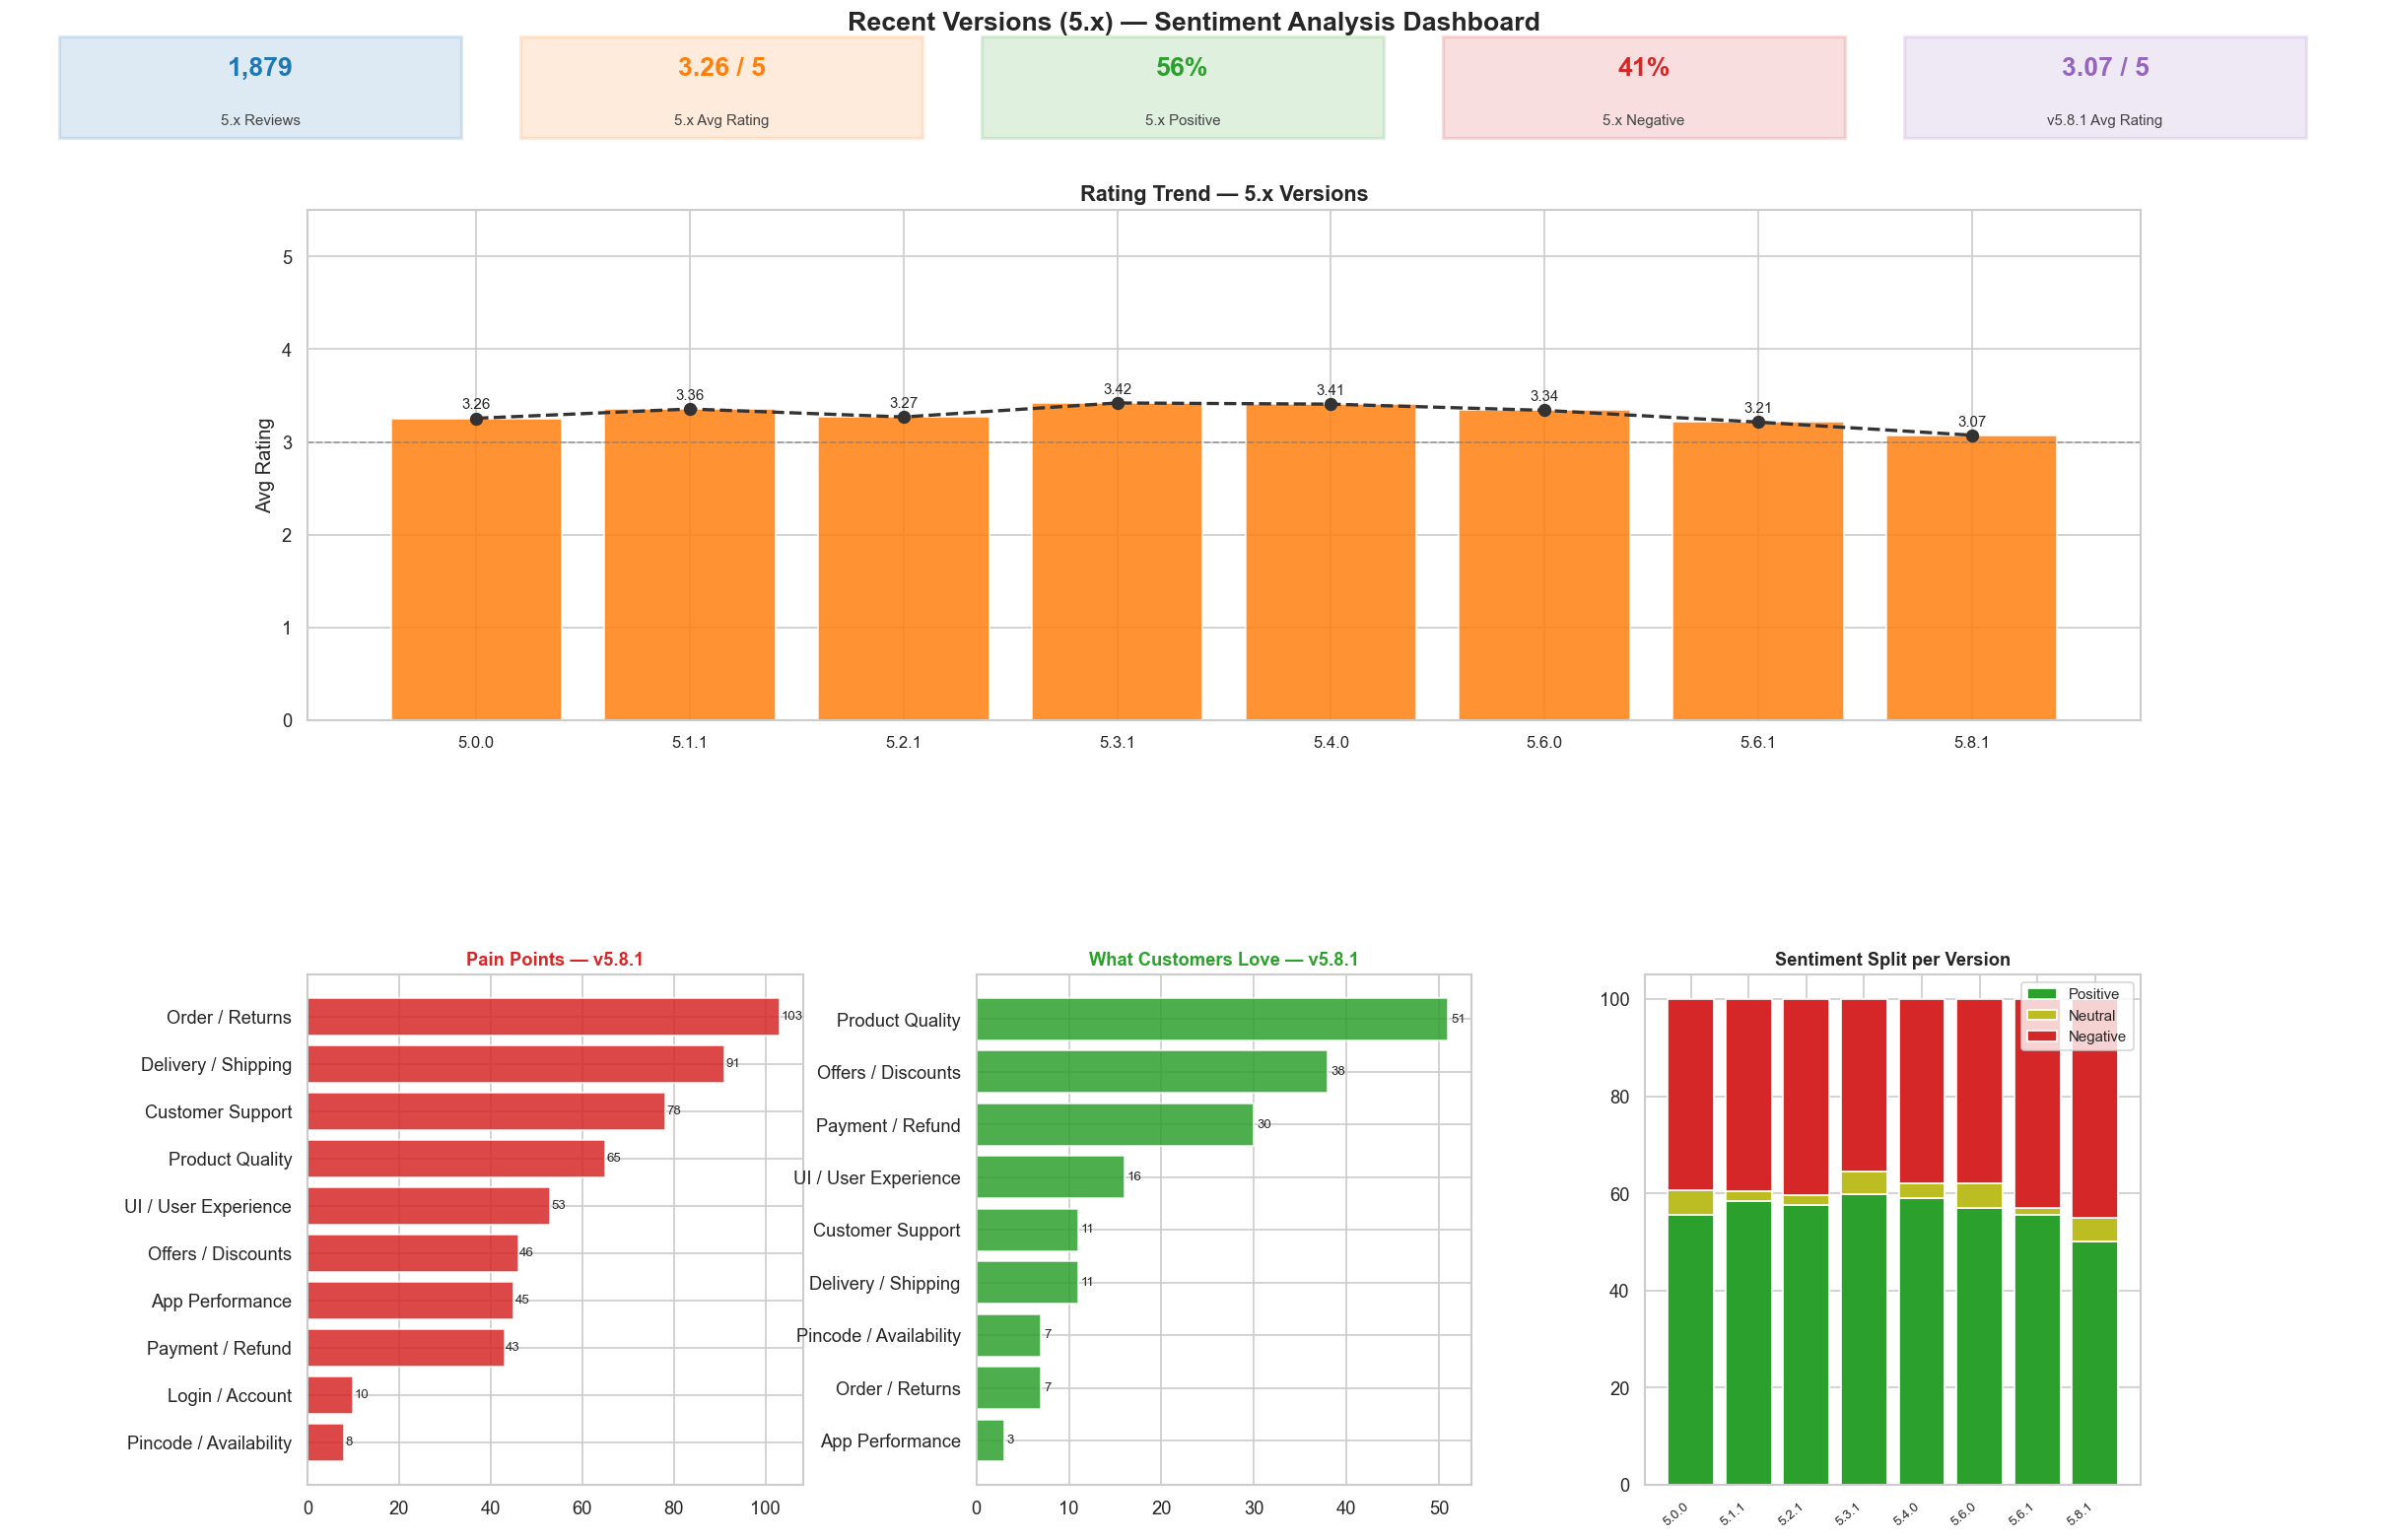

Dashboard saved.


In [12]:
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

# KPI strip
sc5 = df['sentiment'].value_counts()
sp5 = (sc5 / len(df) * 100).round(1)
sc58 = latest['sentiment'].value_counts()
sp58 = (sc58 / len(latest) * 100).round(1)

kpi_ax = fig.add_axes([0, 0.92, 1, 0.07])
kpi_ax.axis('off')
kpi_items = [
    ('5.x Reviews',       f'{len(df):,}',                     '#1f77b4'),
    ('5.x Avg Rating',    f'{df["rating"].mean():.2f} / 5',   '#ff7f0e'),
    ('5.x Positive',      f'{sp5.get("Positive",0):.0f}%',    '#2ca02c'),
    ('5.x Negative',      f'{sp5.get("Negative",0):.0f}%',    '#d62728'),
    ('v5.8.1 Avg Rating', f'{latest["rating"].mean():.2f} / 5','#9467bd'),
]
for i, (label, val, color) in enumerate(kpi_items):
    x = 0.02 + i * 0.195
    kpi_ax.add_patch(plt.Rectangle((x, 0.05), 0.17, 0.88, transform=kpi_ax.transAxes,
                                    color=color, alpha=0.15, linewidth=2, edgecolor=color))
    kpi_ax.text(x + 0.085, 0.65, val, ha='center', va='center', fontsize=16,
                fontweight='bold', color=color, transform=kpi_ax.transAxes)
    kpi_ax.text(x + 0.085, 0.2, label, ha='center', va='center', fontsize=9,
                color='#444', transform=kpi_ax.transAxes)

# Rating trend
ax1 = fig.add_subplot(gs[0, :])
bar_colors_v = ['#2ca02c' if r >= 4 else '#ff7f0e' if r >= 3 else '#d62728' for r in v_stats['avg_rating']]
ax1.bar(range(len(v_stats)), v_stats['avg_rating'], color=bar_colors_v, edgecolor='white', alpha=0.85)
ax1.plot(range(len(v_stats)), v_stats['avg_rating'], 'o--', color='#333', linewidth=2, markersize=7, zorder=5)
ax1.axhline(3, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax1.set_xticks(range(len(v_stats)))
ax1.set_xticklabels(v_stats['app_version'].tolist(), fontsize=10)
ax1.set_ylabel('Avg Rating')
ax1.set_ylim(0, 5.5)
ax1.set_title('Rating Trend — 5.x Versions', fontsize=13, fontweight='bold')
for xi, (_, row) in enumerate(v_stats.iterrows()):
    ax1.text(xi, row['avg_rating'] + 0.1, f"{row['avg_rating']:.2f}", ha='center', fontsize=9)

# Pain points 5.8.1
ax2 = fig.add_subplot(gs[1, 0])
nc_s = neg_counts.sort_values(ascending=True)
nc_s = nc_s[nc_s.index != 'Other']
ax2.barh(nc_s.index, nc_s.values, color='#d62728', edgecolor='white', alpha=0.85)
ax2.set_title('Pain Points — v5.8.1', fontsize=11, fontweight='bold', color='#d62728')
for i, v in enumerate(nc_s.values):
    ax2.text(v + 0.3, i, str(v), va='center', fontsize=8)

# What customers love 5.8.1
ax3 = fig.add_subplot(gs[1, 1])
pc_s = pos_counts.sort_values(ascending=True)
pc_s = pc_s[pc_s.index != 'Other']
ax3.barh(pc_s.index, pc_s.values, color='#2ca02c', edgecolor='white', alpha=0.85)
ax3.set_title('What Customers Love — v5.8.1', fontsize=11, fontweight='bold', color='#2ca02c')
for i, v in enumerate(pc_s.values):
    ax3.text(v + 0.3, i, str(v), va='center', fontsize=8)

# Sentiment split per version
ax4 = fig.add_subplot(gs[1, 2])
xv = range(len(v_stats))
ax4.bar(xv, v_stats['pct_pos'], label='Positive', color='#2ca02c', edgecolor='white')
ax4.bar(xv, v_stats['pct_neu'], bottom=v_stats['pct_pos'], label='Neutral', color='#bcbd22', edgecolor='white')
ax4.bar(xv, v_stats['pct_neg'], bottom=v_stats['pct_pos'] + v_stats['pct_neu'], label='Negative', color='#d62728', edgecolor='white')
ax4.set_xticks(list(xv))
ax4.set_xticklabels(v_stats['app_version'].tolist(), rotation=40, ha='right', fontsize=8)
ax4.set_title('Sentiment Split per Version', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)

fig.suptitle('Recent Versions (5.x) — Sentiment Analysis Dashboard', fontsize=16, fontweight='bold', y=1.0)
plt.savefig('r00_recent_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()
print('Dashboard saved.')

## 12. Key Takeaways — Recent Versions

In [13]:
best_v  = v_stats.nlargest(1, 'avg_rating').iloc[0]
worst_v = v_stats.nsmallest(1, 'avg_rating').iloc[0]
trend_dir = 'IMPROVING' if v_stats.iloc[-1]['avg_rating'] > v_stats.iloc[-3]['avg_rating'] else 'DECLINING'

print('=' * 62)
print('     KEY TAKEAWAYS — RECENT VERSIONS (5.x)')
print('=' * 62)
print(f'\nTotal 5.x Reviews : {len(df):,}')
print(f'Avg Rating (5.x)  : {df["rating"].mean():.2f} / 5.00')
print(f'Positive          : {sp5.get("Positive",0):.1f}%')
print(f'Negative          : {sp5.get("Negative",0):.1f}%')
print(f'\nRating Trend      : {trend_dir}')
print(f'Best 5.x Version  : {best_v["app_version"]} (avg {best_v["avg_rating"]:.2f})')
print(f'Worst 5.x Version : {worst_v["app_version"]} (avg {worst_v["avg_rating"]:.2f})')
print(f'\nLatest (v5.8.1)   : {len(latest)} reviews | avg rating {latest["rating"].mean():.2f}')
print(f'  Positive  : {sp58.get("Positive",0):.1f}%')
print(f'  Negative  : {sp58.get("Negative",0):.1f}%')
print(f'\nTop Pain Points in v5.8.1:')
for t, c in neg_counts.head(5).items():
    print(f'  {t:<28} {c:>4} ({c/len(latest_neg)*100:.1f}% of negatives)')
print(f'\nWhat Customers Love in v5.8.1:')
for t, c in pos_counts.head(5).items():
    print(f'  {t:<28} {c:>4} ({c/len(latest_pos)*100:.1f}% of positives)')
print('\nSaved: r00_recent_dashboard.png through r08_tfidf_latest.png')
print('=' * 62)

     KEY TAKEAWAYS — RECENT VERSIONS (5.x)

Total 5.x Reviews : 1,879
Avg Rating (5.x)  : 3.26 / 5.00
Positive          : 55.8%
Negative          : 40.7%

Rating Trend      : DECLINING
Best 5.x Version  : 5.3.1 (avg 3.42)
Worst 5.x Version : 5.8.1 (avg 3.07)

Latest (v5.8.1)   : 385 reviews | avg rating 3.07
  Positive  : 50.1%
  Negative  : 44.9%

Top Pain Points in v5.8.1:
  Order / Returns               103 (59.5% of negatives)
  Delivery / Shipping            91 (52.6% of negatives)
  Customer Support               78 (45.1% of negatives)
  Product Quality                65 (37.6% of negatives)
  UI / User Experience           53 (30.6% of negatives)

What Customers Love in v5.8.1:
  Product Quality                51 (26.4% of positives)
  Offers / Discounts             38 (19.7% of positives)
  Payment / Refund               30 (15.5% of positives)
  UI / User Experience           16 (8.3% of positives)
  Delivery / Shipping            11 (5.7% of positives)

Saved: r00_recent_das